In [3]:
import re
import numpy as np
import matplotlib.pyplot as plt

#read file
with open("horizons_results.txt", "r", encoding="utf-8") as f:
    text = f.read()

#only take the data between $$SOE and $$EOE 
start = text.index("$$SOE") + len("$$SOE")
end = text.index("$$EOE") if "$$EOE" in text else len(text)
data_block = text[start:end].strip()

lines = [line.strip() for line in data_block.splitlines() if line.strip()]

times = []
x_list, y_list, z_list = [], [], []
vx_list, vy_list, vz_list = [], [], []

#parse the Horizons vector table
i = 0
while i < len(lines) - 2:
    time_line = lines[i] #time
    pos_line = lines[i + 1] #X Y Z
    vel_line = lines[i + 2] #VX VY VZ

    if "X =" not in pos_line:
        i += 1
        continue

    times.append(time_line)

    x = float(re.search(r"X\s*=\s*([-\d.E+]+)", pos_line).group(1))
    y = float(re.search(r"Y\s*=\s*([-\d.E+]+)", pos_line).group(1))
    z = float(re.search(r"Z\s*=\s*([-\d.E+]+)", pos_line).group(1))

    vx = float(re.search(r"VX\s*=\s*([-\d.E+]+)", vel_line).group(1))
    vy = float(re.search(r"VY\s*=\s*([-\d.E+]+)", vel_line).group(1))
    vz = float(re.search(r"VZ\s*=\s*([-\d.E+]+)", vel_line).group(1))

    x_list.append(x)
    y_list.append(y)
    z_list.append(z)
    vx_list.append(vx)
    vy_list.append(vy)
    vz_list.append(vz)

    i += 3

#convert to numpy array
x = np.array(x_list)
y = np.array(y_list)
z = np.array(z_list)
vx = np.array(vx_list)
vy = np.array(vy_list)
vz = np.array(vz_list)

print("Number of data points:", len(x))
print("First X,Y,Z:", x[0], y[0], z[0])

Number of data points: 220
First X,Y,Z: 1156437444.479337 -3241534628.849548 158130543.4196271


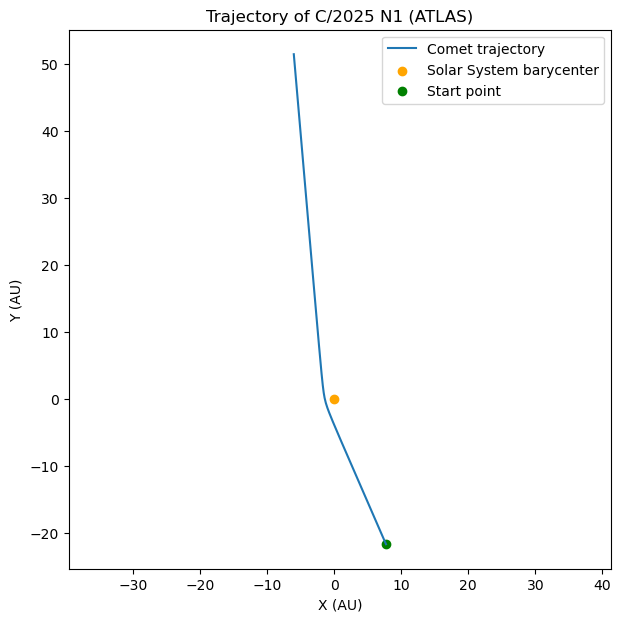

In [4]:
AU = 1.495978707e8 #convert km -> AU

x_au = x / AU
y_au = y / AU

plt.figure(figsize=(7,7)) #plot comet trajectory

plt.plot(x_au, y_au, label="Comet trajectory")
plt.scatter(0,0,color="orange", label="Solar System barycenter")

plt.scatter(x_au[0], y_au[0], color="green", label="Start point")

plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.title("Trajectory of C/2025 N1 (ATLAS)")

plt.legend()

plt.axis("equal")
plt.show()

In [5]:
r = np.sqrt(x**2 + y**2 + z**2)

min_r = np.min(r)
min_index = np.argmin(r)

print("Minimum distance to Sun (AU):", min_r)
print("Time of closest approach:", times[min_index])

Minimum distance to Sun (AU): 204049431.79366973
Time of closest approach: 2460980.500000000 = A.D. 2025-Nov-01 00:00:00.0000 TDB
